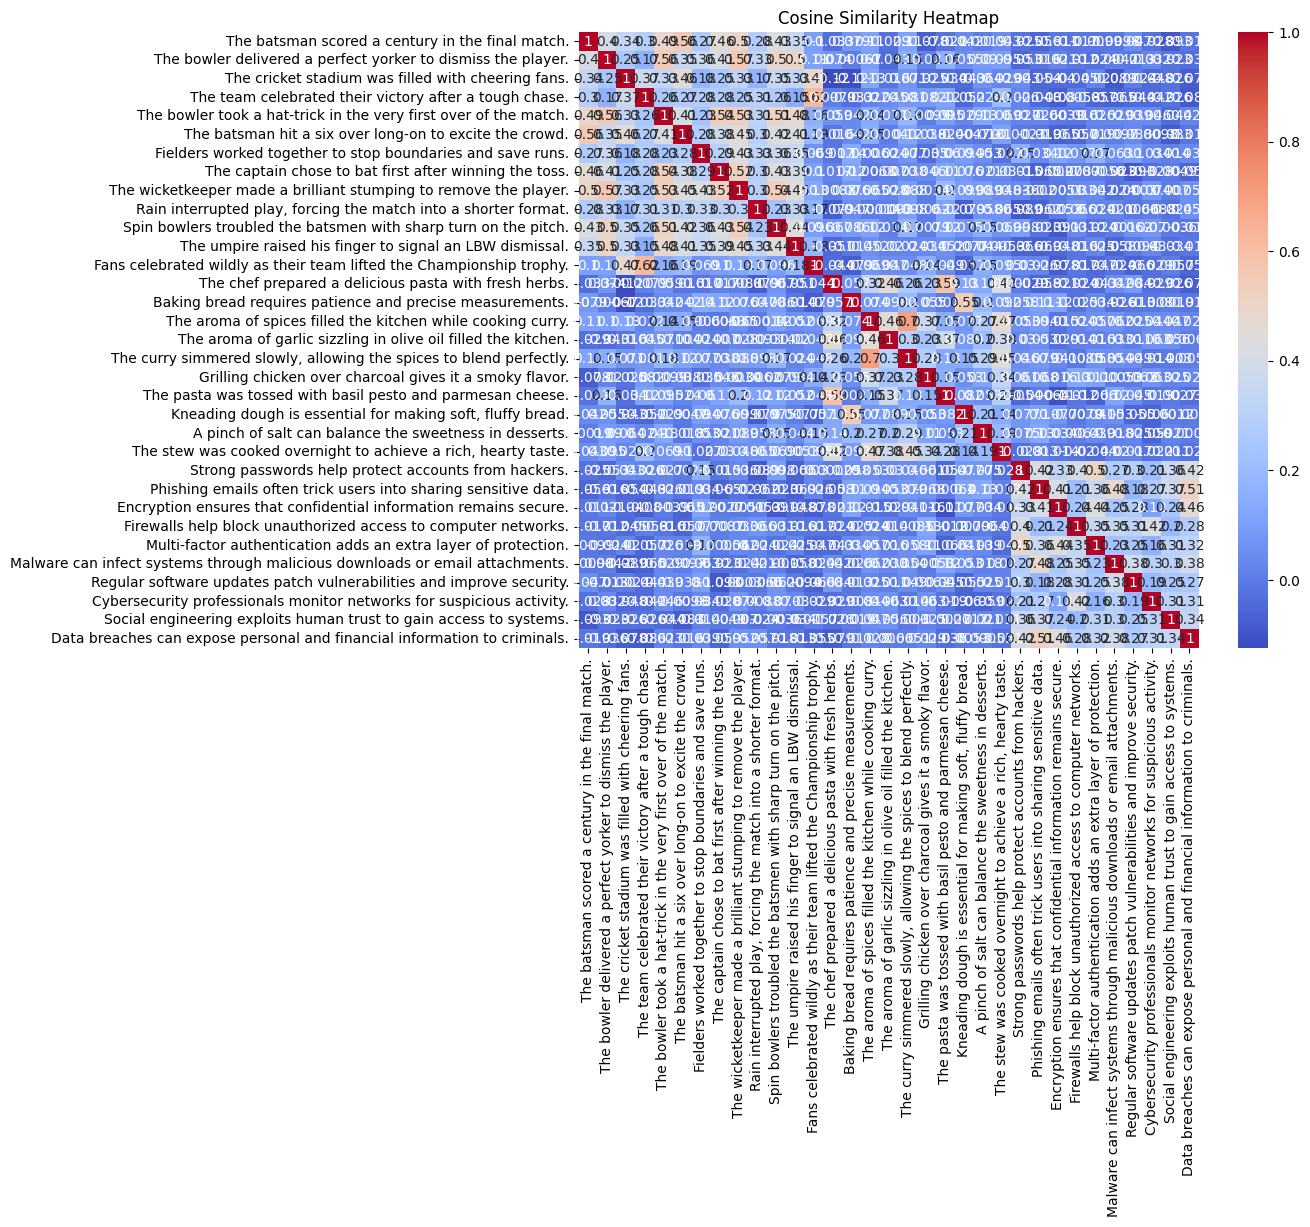



Query: The bowler took three wickets in one over
Sentence: The bowler took a hat-trick in the very first over of the match. | Similarity: 0.6545
Sentence: The batsman scored a century in the final match. | Similarity: 0.5679


In [5]:
# Install sentence-transformers if not already
#!pip install -q sentence-transformers matplotlib seaborn
#!pip install transformers==4.50.3

from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Write 10 sentences across 3 topics
sentences = [
    # Cricket
    "The batsman scored a century in the final match.",
    "The bowler delivered a perfect yorker to dismiss the player.",
    "The cricket stadium was filled with cheering fans.",
    "The team celebrated their victory after a tough chase.",
    "The bowler took a hat-trick in the very first over of the match.",
    "The batsman hit a six over long-on to excite the crowd.",
    "Fielders worked together to stop boundaries and save runs.",
    "The captain chose to bat first after winning the toss.",
    "The wicketkeeper made a brilliant stumping to remove the player.",
    "Rain interrupted play, forcing the match into a shorter format.",
    "Spin bowlers troubled the batsmen with sharp turn on the pitch.",
    "The umpire raised his finger to signal an LBW dismissal.",
    "Fans celebrated wildly as their team lifted the Championship trophy.",


    # Cooking
    "The chef prepared a delicious pasta with fresh herbs.",
    "Baking bread requires patience and precise measurements.",
    "The aroma of spices filled the kitchen while cooking curry.",
    "The aroma of garlic sizzling in olive oil filled the kitchen.",
    "The curry simmered slowly, allowing the spices to blend perfectly.",
    "Grilling chicken over charcoal gives it a smoky flavor.",
    "The pasta was tossed with basil pesto and parmesan cheese.",
    "Kneading dough is essential for making soft, fluffy bread.",
    "A pinch of salt can balance the sweetness in desserts.",
    "The stew was cooked overnight to achieve a rich, hearty taste.",


    # Cybersecurity
    "Strong passwords help protect accounts from hackers.",
    "Phishing emails often trick users into sharing sensitive data.",
    "Encryption ensures that confidential information remains secure.",
    "Firewalls help block unauthorized access to computer networks.",
    "Multi-factor authentication adds an extra layer of protection.",
    "Malware can infect systems through malicious downloads or email attachments.",
    "Regular software updates patch vulnerabilities and improve security.",
    "Cybersecurity professionals monitor networks for suspicious activity.",
    "Social engineering exploits human trust to gain access to systems.",
    "Data breaches can expose personal and financial information to criminals.",

]

# Step 2: Load model and generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2', token=False)
embeddings = model.encode(sentences, convert_to_tensor=True)

# Step 3: Compute cosine similarity matrix
cosine_sim = util.cos_sim(embeddings, embeddings).cpu().numpy()
#print(cosine_sim)

# Step 4: Display heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cosine_sim, annot=True, cmap="coolwarm", xticklabels=sentences, yticklabels=sentences)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Cosine Similarity Heatmap")
plt.show()

# Step 5: New query sentence
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

# Step 6: Find top 2 most similar sentences
similarities = util.cos_sim(query_embedding, embeddings).cpu().numpy()[0]
top_indices = similarities.argsort()[-2:][::-1]

print()
print()
print("Query:", query)
for idx in top_indices:
    print(f"Sentence: {sentences[idx]} | Similarity: {similarities[idx]:.4f}")